# 金庸小说人名词嵌套

通过对金庸小说集全人物列表进行筛选，让chatgpt选出最重要的人物，要求涵盖15部小说，形成personlist.txt，共计133位人物。然后通过加载停用词，预处理金庸小说集全集文本，使用word2vec进行训练模型进行词嵌套，对133个人物进行向量语义表示，分别投射到二维和三维向量上

主要任务包括：
1.通过分析小说文本，学习每个人物的语义特征
2.将高维的人物向量降维到2维或3维
3.通过可视化展示人物之间的关系
4.通过聚类分析找出相似的人物群体

In [ ]:
import os
import jieba
from gensim.models import Word2Vec
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from tqdm import tqdm
import pickle
from collections import defaultdict
from adjustText import adjust_text  # 用于调整标签位置，避免重叠

# 设置matplotlib中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

def load_stop_words(file_path):
    """加载停用词表
    Args:
        file_path: 停用词表文件路径
    Returns:
        set: 停用词集合
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        stop_words = set(line.strip() for line in f if line.strip())
    return stop_words

def process_text_file(file_path, stop_words, characters):
    """处理单个文本文件，返回句子列表
    Args:
        file_path: 文本文件路径
        stop_words: 停用词集合
        characters: 人物名称字典
    Returns:
        list: 句子列表，每个句子是词列表
    """
    # 将所有人物名称添加到jieba词典中，确保人物名称不会被错误分词
    for name in characters.keys():
        jieba.add_word(name)
        if characters[name]:  # 如果有别名，也添加到词典中
            jieba.add_word(characters[name])
    
    # 定义句子分隔符
    sentence_endings = ['。', '！', '？', '；', '……', '——', '\n', '…', '—']  # 句末分隔符
    sentence_continuations = ['，', '、', '：', '；', '（', '）', '"', '"', '「', '」', '『', '』']  # 句中分隔符
    
    sentences = []
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
        # 清理文本
        text = clean_text(text)
        
        # 使用jieba分词
        words = jieba.lcut(text)
        
        # 将文本分割成句子
        current_sentence = []
        for word in words:
            if word in sentence_endings:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            elif word in sentence_continuations:
                # 如果当前句子不为空，则继续当前句子
                if current_sentence:
                    current_sentence.append(word)
            elif word not in stop_words:  # 只保留非停用词
                current_sentence.append(word)
        
        # 处理最后一个句子
        if current_sentence:
            sentences.append(current_sentence)
    
    # 过滤掉过短的句子
    return [s for s in sentences if len(s) >= 3]

def clean_text(text):
    """清理文本中的标点符号
    Args:
        text: 原始文本
    Returns:
        str: 清理后的文本
    """
    # 替换连续的标点符号为单个标点
    text = re.sub(r'[。！？；]+', '。', text)  # 将连续的句末标点替换为句号
    text = re.sub(r'[，、；]+', '，', text)    # 将连续的句中标点替换为逗号
    text = re.sub(r'[……]+', '……', text)      # 将连续的省略号标准化
    text = re.sub(r'[——]+', '——', text)      # 将连续的破折号标准化
    # 处理对话中的引号
    text = re.sub(r'[""]+', '"', text)
    text = re.sub(r'[「」]+', '「', text)
    text = re.sub(r'[『』]+', '『', text)
    return text

def load_character_list(file_path):
    """加载人物列表，处理别名
    Args:
        file_path: 人物列表文件路径
    Returns:
        dict: 人物名称字典，键为主名，值为别名
    """
    characters = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # 使用正则表达式匹配括号中的别名
            match = re.match(r'(.+?)（(.+?)）', line)
            if match:
                main_name = match.group(1)
                alias = match.group(2)
                characters[main_name] = alias
            else:
                characters[line] = None
    return characters

def train_word2vec(sentences, vector_size=200, window=8, min_count=5, workers=4, epochs=10):
    """训练Word2Vec模型
    Args:
        sentences: 句子列表
        vector_size: 词向量维度
        window: 窗口大小
        min_count: 最小词频
        workers: 并行数
        epochs: 训练轮数
    Returns:
        Word2Vec: 训练好的模型
    """
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        epochs=epochs,
        sg=1,  # 使用skip-gram模型
        hs=0,  # 使用负采样
        negative=5,  # 负采样数量
        ns_exponent=0.75  # 负采样指数
    )
    return model

def get_character_vector(model, main_name, alias=None):
    """获取人物向量，处理别名情况
    Args:
        model: Word2Vec模型
        main_name: 主要名称
        alias: 别名
    Returns:
        np.ndarray: 人物向量，如果找不到则返回None
    """
    vectors = []
    try:
        vectors.append(model.wv[main_name])
    except KeyError:
        pass
    
    if alias:
        try:
            vectors.append(model.wv[alias])
        except KeyError:
            pass
    
    if not vectors:
        return None
    
    # 如果有多个向量（原名和别名都有），取平均值
    return np.mean(vectors, axis=0)

def plot_2d(vectors, characters, clusters=None, save_path='characters_2d.png'):
    """绘制2D可视化图
    Args:
        vectors: 2D向量
        characters: 人物名称列表
        clusters: 聚类结果
        save_path: 保存路径
    """
    plt.figure(figsize=(20, 20))
    
    # 绘制散点图
    if clusters is not None:
        scatter = plt.scatter(vectors[:, 0], vectors[:, 1], c=clusters, cmap='tab20', s=100)
        plt.colorbar(scatter)
    else:
        plt.scatter(vectors[:, 0], vectors[:, 1], s=100)
    
    # 添加标签，使用更透明的方式
    texts = []
    for i, char in enumerate(characters):
        texts.append(plt.text(
            vectors[i, 0],
            vectors[i, 1],
            char,
            fontsize=8,
            alpha=0.7,  # 设置透明度
            ha='center',
            va='center'
        ))
    
    # 调整标签位置，避免重叠
    adjust_text(texts, 
                only_move={'points':'y', 'text':'y'},  # 只允许垂直移动
                arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
    
    plt.title('金庸小说人物关系2D可视化', fontsize=16, fontproperties='SimHei')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # 保存图片
    plt.savefig(save_path, dpi=300, bbox_inches='tight', format='png')
    plt.close()

def plot_3d(vectors, characters, clusters=None, save_path='characters_3d.png'):
    """绘制3D可视化图
    Args:
        vectors: 3D向量
        characters: 人物名称列表
        clusters: 聚类结果
        save_path: 保存路径
    """
    fig = plt.figure(figsize=(20, 20))
    ax = fig.add_subplot(111, projection='3d')
    
    # 绘制散点图
    if clusters is not None:
        scatter = ax.scatter(vectors[:, 0], vectors[:, 1], vectors[:, 2], 
                           c=clusters, cmap='tab20', s=100)
        plt.colorbar(scatter)
    else:
        ax.scatter(vectors[:, 0], vectors[:, 1], vectors[:, 2], s=100)
    
    # 添加标签，使用更透明的方式
    for i, char in enumerate(characters):
        ax.text(
            vectors[i, 0], 
            vectors[i, 1], 
            vectors[i, 2],
            char,
            fontsize=8,
            alpha=0.7,  # 设置透明度
            ha='center',
            va='center'
        )
    
    ax.set_title('金庸小说人物关系3D可视化', fontsize=16, fontproperties='SimHei')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # 调整视角以获得更好的显示效果
    ax.view_init(elev=20, azim=45)
    
    # 保存图片
    plt.savefig(save_path, dpi=300, bbox_inches='tight', format='png')
    plt.close()

def main():
    """主函数"""
    # 加载停用词表
    print("正在加载停用词表...")
    stop_words = load_stop_words('stop_words.txt')
    
    # 加载人物列表
    print("正在加载人物列表...")
    characters = load_character_list('personlist.txt')
    
    # 处理文本文件
    print("正在处理文本文件...")
    all_sentences = []
    folder_path = '金庸小说全集'
    for filename in tqdm(os.listdir(folder_path)):
        if filename.endswith('.txt'):
            file_path = os.path.join(folder_path, filename)
            sentences = process_text_file(file_path, stop_words, characters)
            all_sentences.extend(sentences)
    
    # 训练Word2Vec模型
    print("正在训练Word2Vec模型...")
    model = train_word2vec(all_sentences)
    
    # 保存模型
    model.save('jinyong_word2vec.model')
    
    # 获取人物向量
    print("正在获取人物向量...")
    character_vectors = []
    valid_characters = []
    for main_name, alias in tqdm(characters.items()):
        vector = get_character_vector(model, main_name, alias)
        if vector is not None:
            character_vectors.append(vector)
            valid_characters.append(main_name)
        else:
            print(f"警告：找不到人物 '{main_name}' 的向量")
    
    character_vectors = np.array(character_vectors)
    
    # 进行聚类分析
    print("正在进行聚类分析...")
    n_clusters = min(20, len(valid_characters) // 2)  # 根据人物数量动态确定聚类数
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(character_vectors)
    
    # 2D PCA
    print("正在进行2D PCA降维...")
    pca_2d = PCA(n_components=2)
    vectors_2d = pca_2d.fit_transform(character_vectors)
    plot_2d(vectors_2d, valid_characters, clusters, 'characters_2d.png')
    
    # 3D PCA
    print("正在进行3D PCA降维...")
    pca_3d = PCA(n_components=3)
    vectors_3d = pca_3d.fit_transform(character_vectors)
    plot_3d(vectors_3d, valid_characters, clusters, 'characters_3d.png')
    
    # 保存聚类结果
    cluster_results = defaultdict(list)
    for char, cluster in zip(valid_characters, clusters):
        cluster_results[cluster].append(char)
    
    with open('cluster_results.txt', 'w', encoding='utf-8') as f:
        for cluster, chars in cluster_results.items():
            f.write(f"聚类 {cluster}:\n")
            f.write(", ".join(chars) + "\n\n")
    
    print("处理完成！已生成2D和3D可视化文件，以及聚类结果。")

if __name__ == "__main__":
    main() 

其中需要注意的是，persionlist中部分人物有别名，为xxx（xxx）的形式，括号中为别名，需要同时对两个名称进行向量表示然后取均值。

可视化结果如下：
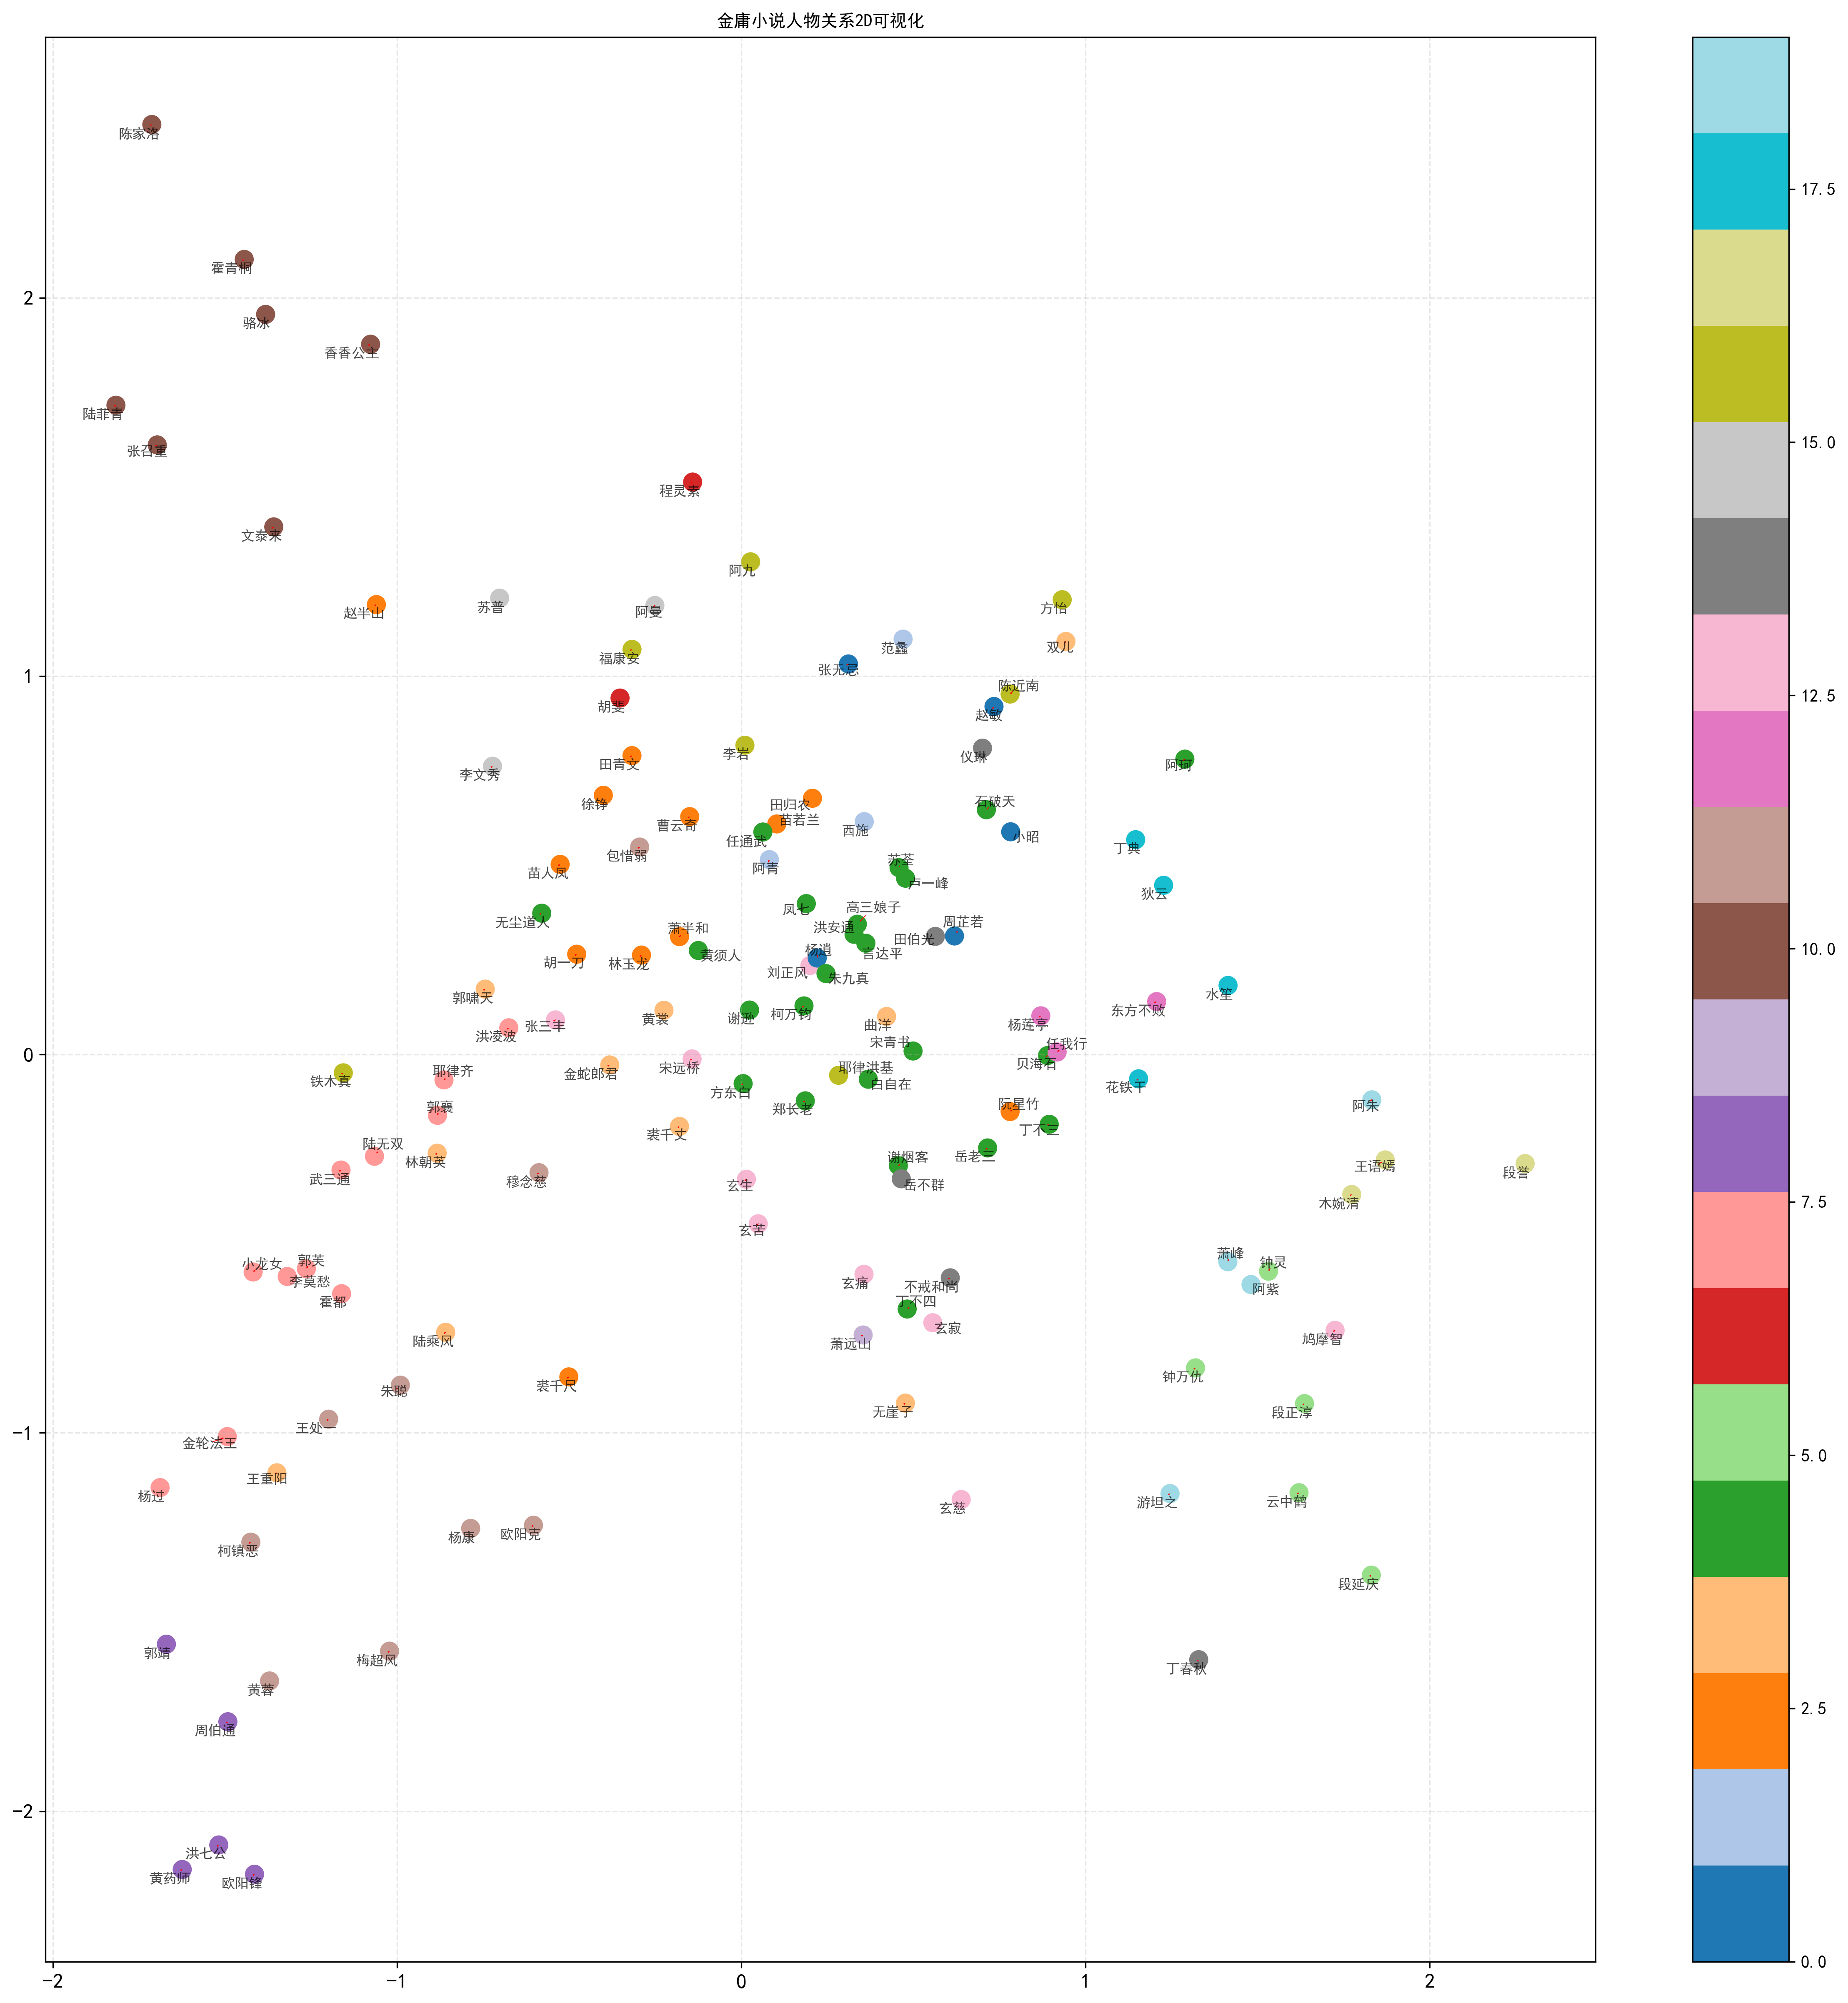
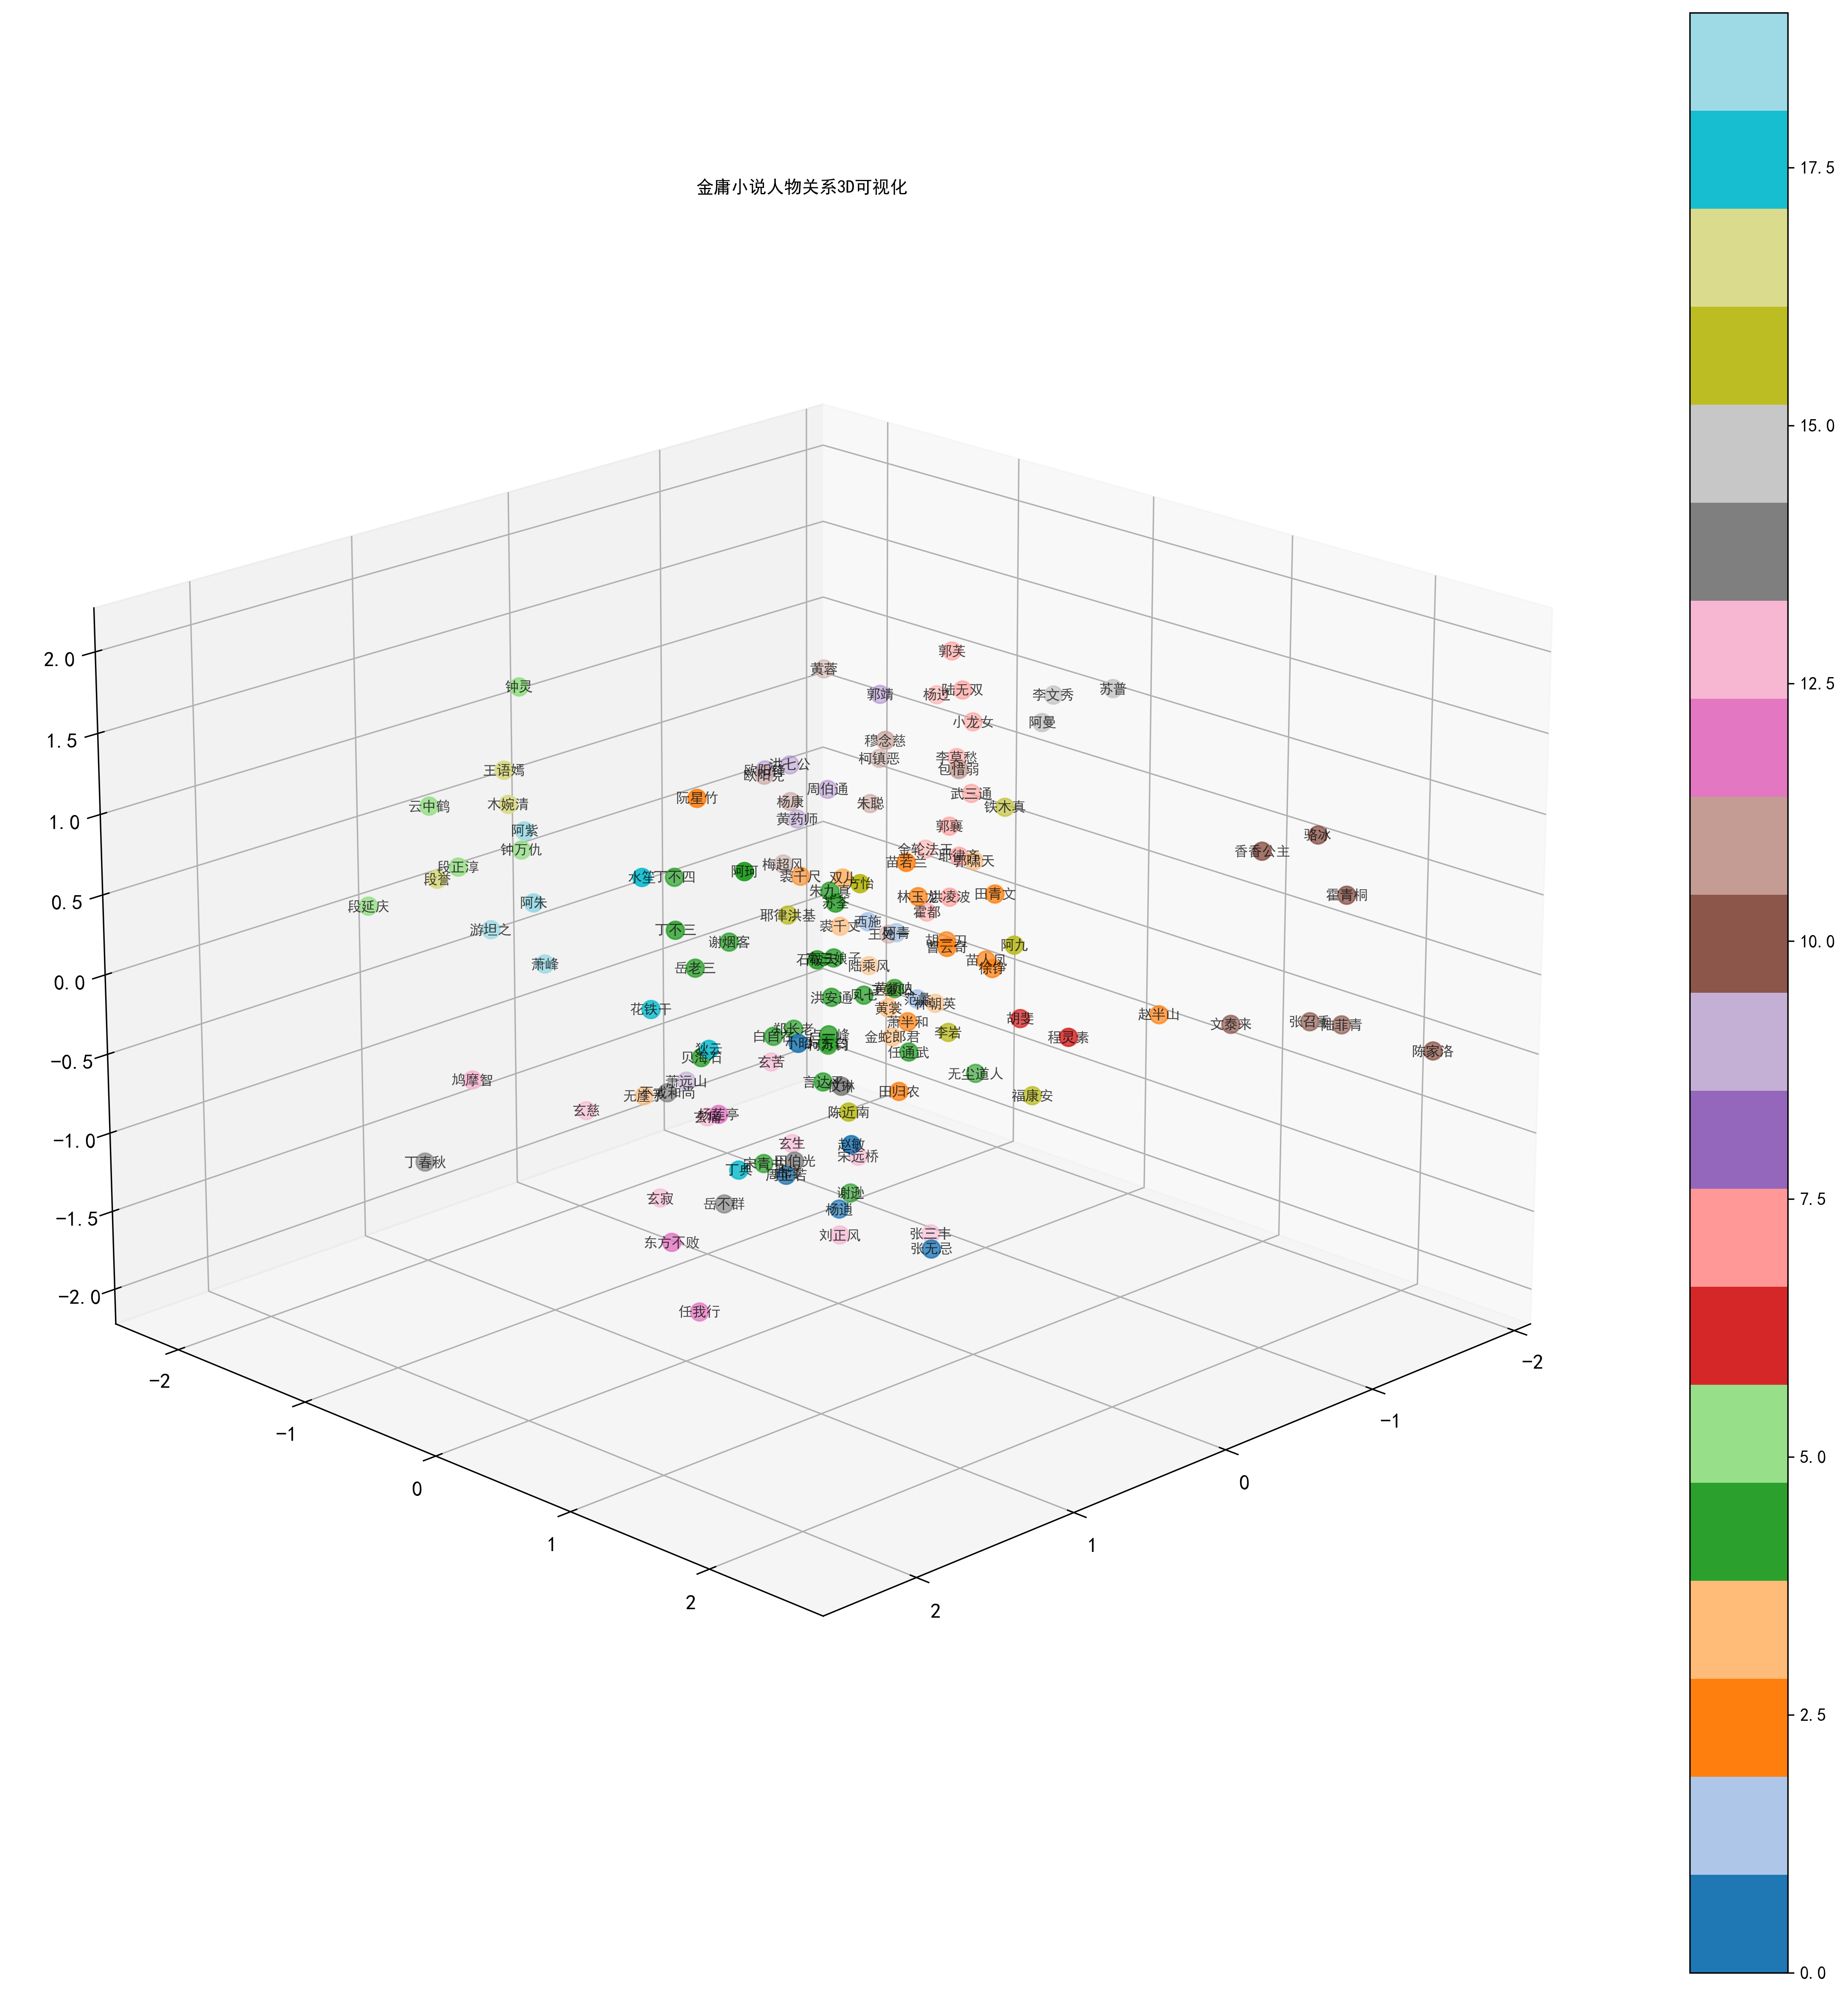

聚类结果如下：

聚类 16:
阿九, 陈近南, 方怡, 福康安, 李岩, 铁木真, 耶律洪基

聚类 4:
阿珂, 白自在, 贝海石, 丁不三, 丁不四, 方东白, 凤七, 高三娘子, 洪安通, 黄须人, 卢一峰, 石破天, 宋青书, 苏荃, 无尘道人, 谢烟客, 谢逊, 言达平, 郑长老, 朱九真, 柯万钧, 岳老三, 任通武

聚类 15:
阿曼, 李文秀, 苏普

聚类 1:
阿青, 范蠡, 西施

聚类 19:
阿紫, 阿朱, 萧峰, 游坦之

聚类 11:
包惜弱, 黄蓉, 柯镇恶, 梅超风, 穆念慈, 欧阳克, 王处一, 杨康, 朱聪

聚类 14:
不戒和尚, 丁春秋, 田伯光, 仪琳, 岳不群

聚类 2:
曹云奇, 胡一刀, 林玉龙, 苗人凤, 苗若兰, 裘千尺, 阮星竹, 田归农, 田青文, 萧半和, 徐铮, 赵半山

聚类 6:
程灵素, 胡斐

聚类 10:
陈家洛, 霍青桐, 文泰来, 香香公主, 张召重, 陆菲青, 骆冰

聚类 18:
丁典, 花铁干, 狄云, 水笙

聚类 12:
东方不败, 任我行, 杨莲亭

聚类 17:
段誉, 木婉清, 王语嫣

聚类 5:
段延庆, 段正淳, 云中鹤, 钟万仇, 钟灵

聚类 3:
郭啸天, 黄裳, 曲洋, 双儿, 王重阳, 无崖子, 金蛇郎君, 陆乘风, 林朝英, 裘千丈

聚类 7:
郭襄, 郭芙, 洪凌波, 霍都, 金轮法王, 李莫愁, 武三通, 小龙女, 杨过, 陆无双, 耶律齐

聚类 8:
郭靖, 洪七公, 黄药师, 欧阳锋, 周伯通

聚类 13:
刘正风, 宋远桥, 玄慈, 玄苦, 玄寂, 玄生, 玄痛, 张三丰, 鸠摩智

聚类 0:
小昭, 杨逍, 张无忌, 赵敏, 周芷若

聚类 9:
萧远山